# Paper figures

Interactive version of `scripts/make_paper_figures.py`. Regenerates the four figures used in `paper/main.tex` from `results/*.csv`.

The plotting logic lives in `src.vis.paper_figures` (pure functions that take DataFrames and return `matplotlib` Figures). This notebook only loads the CSVs, renders each figure inline, and optionally writes PDF + PNG to `paper/figures/`.

| stem | where in paper |
| --- | --- |
| `mrr_vs_visibility` | main text |
| `mrr_per_topology` | appendix |
| `scalability` | main text |
| `convergence_vs_alpha` | appendix |

In [1]:
%load_ext autoreload
%autoreload 2

# ignore warning
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
from pathlib import Path

import pandas as pd

In [3]:

# Make the `src` package importable when running from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vis.paper_figures import (
    TOPOLOGIES,
    plot_iterations_vs_alpha,
    plot_mrr_by_topology,
    plot_mrr_vs_visibility,
    plot_runtime_memory_scalability,
)
from src.vis.style import set_publication_style

RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures"

set_publication_style()
FIGURES.mkdir(parents=True, exist_ok=True)

In [4]:
def load_mean_comparison() -> pd.DataFrame:
    """Unweighted mean of the three per-topology comparison CSVs."""
    frames = [
        pd.read_csv(RESULTS / f"full_comparison_metrics_CG{i}.csv")
        for i in TOPOLOGIES
    ]
    df = pd.concat(frames, ignore_index=True)
    return df.groupby(["visibility", "method"], as_index=False)[
        ["PR@1", "PR@3", "PR@5", "MRR", "avg_rank"]
    ].mean()


def load_mrr_by_topology(visibility: float = 0.3) -> pd.DataFrame:
    """Wide frame: index=method, one column per topology id, MRR values."""
    cols = {}
    for i in TOPOLOGIES:
        df = pd.read_csv(RESULTS / f"full_comparison_metrics_CG{i}.csv")
        cols[i] = df[df["visibility"] == visibility].set_index("method")["MRR"]
    return pd.DataFrame(cols)


def save(fig, stem: str) -> None:
    fig.savefig(FIGURES / f"{stem}.pdf")
    print(f"wrote {FIGURES / stem}.pdf")

## MRR vs root-cause visibility (main text)

wrote /home/vlq26735/PROJECTS/RESEARCH/eirwr-rca/results/figures/mrr_vs_visibility.pdf


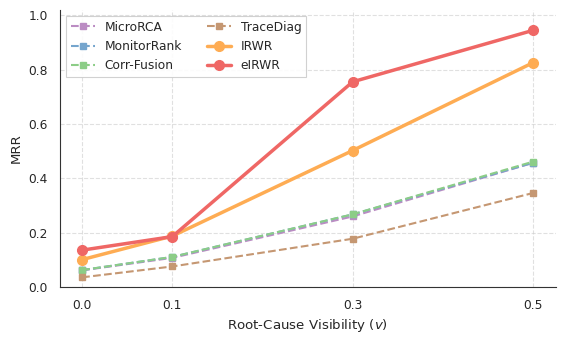

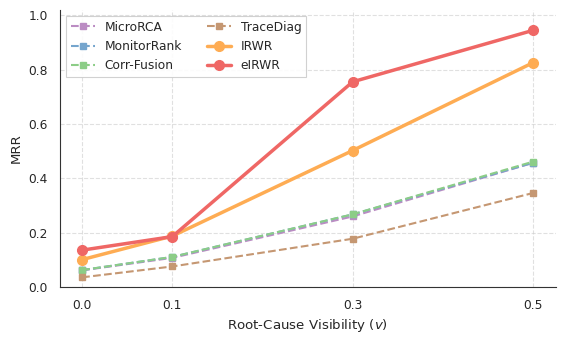

In [5]:
fig = plot_mrr_vs_visibility(load_mean_comparison())
save(fig, "mrr_vs_visibility")
fig

## MRR by method across topologies (appendix)

wrote /home/vlq26735/PROJECTS/RESEARCH/eirwr-rca/results/figures/mrr_per_topology.pdf


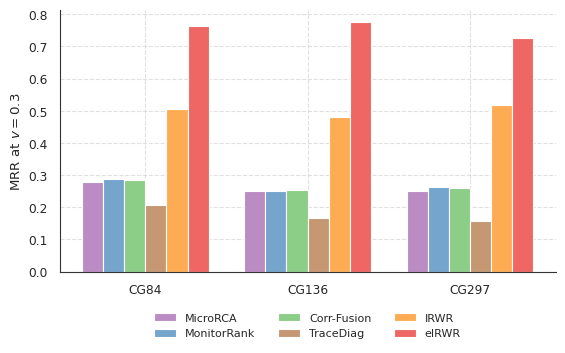

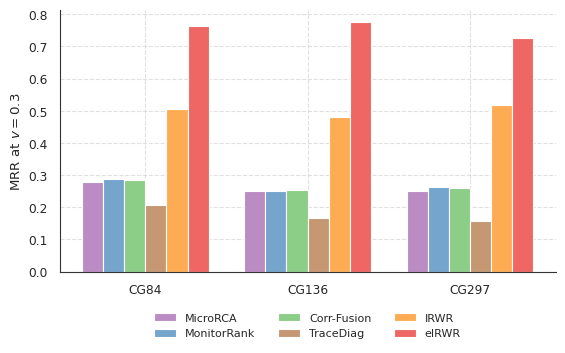

In [6]:
fig = plot_mrr_by_topology(load_mrr_by_topology())
save(fig, "mrr_per_topology")
fig

## Runtime & peak memory vs graph size (main text)

wrote /home/vlq26735/PROJECTS/RESEARCH/eirwr-rca/results/figures/scalability.pdf


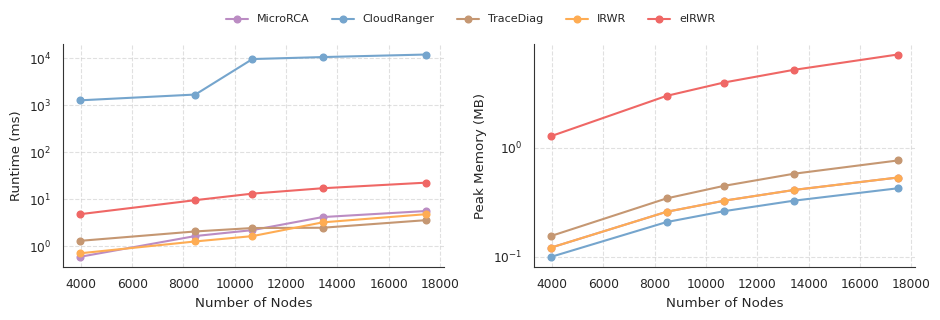

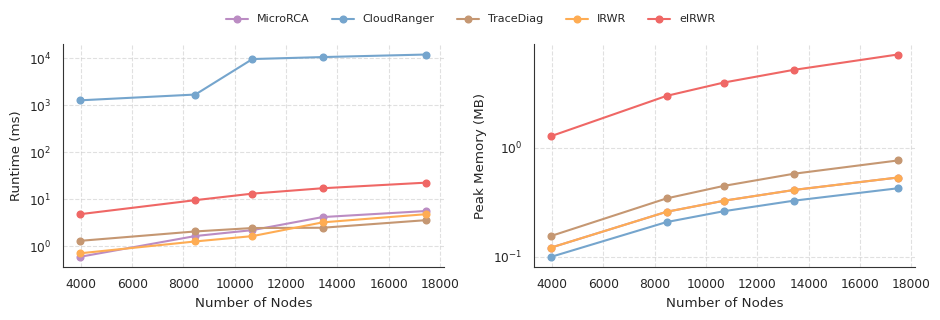

In [7]:
fig = plot_runtime_memory_scalability(
    pd.read_csv(RESULTS / "computational_metrics.csv")
)
save(fig, "scalability")
fig

## Iterations to convergence vs restart probability (appendix)

wrote /home/vlq26735/PROJECTS/RESEARCH/eirwr-rca/results/figures/convergence_vs_alpha.pdf


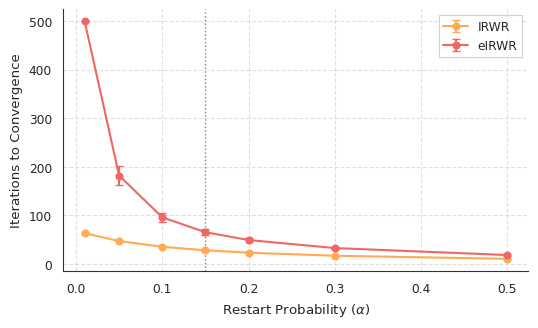

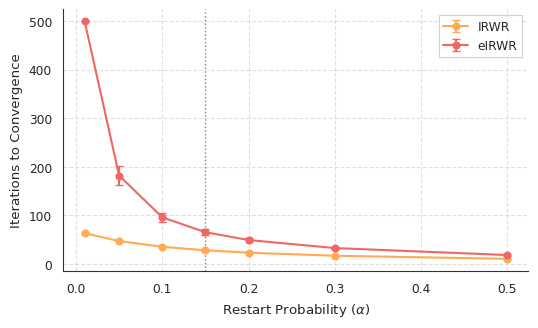

In [8]:
fig = plot_iterations_vs_alpha(
    pd.read_csv(RESULTS / "convergence_metrics.csv")
)
save(fig, "convergence_vs_alpha")
fig